In [ ]:
"""Objective

Evaluate the final trained model using multiple metrics and visualizations."""

In [ ]:
"""Load Best Model
        │
        ▼
Load Engineered Dataset
        │
        ▼
Train-Test Split
        │
        ▼
Predictions
        │
        ▼
Evaluation Metrics
        │
        ▼
Visualizations
        │
        ▼
Cross Validation
        │
        ▼
Save Results"""

In [ ]:
"""# 🏦 Credit Risk Prediction System

# 06 - Model Evaluation

---

## Objectives

- Load the trained model
- Evaluate performance
- Visualize results
- Analyze errors
- Save evaluation outputs"""

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Engineered Dataset
# ==========================================================

df = pd.read_csv("../data/processed/engineered_credit_data.csv")

print(df.shape)

df.head()

(1000, 34)


,num__Unnamed: 0,num__Age,num__Job,num__Credit amount,num__Duration,num__Credit_Per_Month,num__Credit_Age_Ratio,num__Age_Duration_Product,num__Credit_Age_Product,num__Log_Credit_Amount,...,cat__Checking account_rich,cat__Purpose_business,cat__Purpose_car,cat__Purpose_domestic appliances,cat__Purpose_education,cat__Purpose_furniture/equipment,cat__Purpose_radio/TV,cat__Purpose_repairs,cat__Purpose_vacation/others,Risk
0,-1.730320,2.766456,0.146949,-0.745131,-1.236478,0.176948,-0.899591,-0.669863,-0.334336,-0.933992,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,-1.726856,-1.191404,0.146949,0.949817,2.248194,-0.284901,1.874923,0.633721,0.116504,1.163149,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,-1.723391,1.183312,-1.383771,-0.416562,-0.738668,0.045495,-0.621893,-0.299119,-0.125360,-0.181750,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
3,-1.719927,0.831502,0.146949,1.634247,1.750384,0.130233,0.829548,2.296089,2.034481,1.525385,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
4,-1.716463,1.535122,0.146949,0.566664,0.256953,0.229637,-0.083427,1.064262,1.206668,0.904761,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [3]:
# ==========================================================
# Load Best Model
# ==========================================================

model = joblib.load("../models/best_model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [4]:
# ==========================================================
# Split Dataset
# ==========================================================

X = df.drop("Risk", axis=1)

y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 33)
(200, 33)


In [5]:
# ==========================================================
# Predictions
# ==========================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

print("Predictions Completed")

Predictions Completed


In [6]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc = roc_auc_score(y_test, y_prob)

metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

})

metrics

,Metric,Value
0,Accuracy,0.770000
1,Precision,0.779762
2,Recall,0.935714
3,F1 Score,0.850649
4,ROC AUC,0.767857


In [7]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.72      0.38      0.50        60
           1       0.78      0.94      0.85       140

    accuracy                           0.77       200
   macro avg       0.75      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200



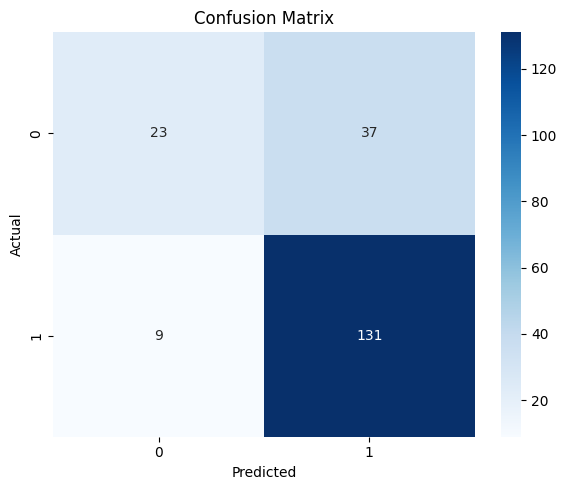

In [8]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

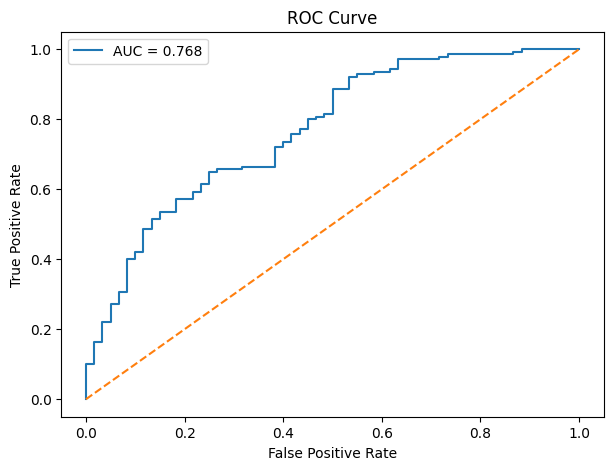

In [9]:
# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

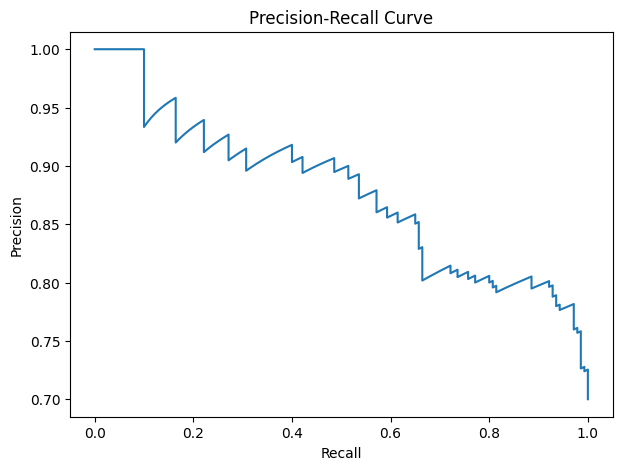

In [10]:
# ==========================================================
# Precision Recall Curve
# ==========================================================

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [11]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
5,num__Credit_Per_Month,0.103932
21,cat__Checking account_No Account,0.081754
6,num__Credit_Age_Ratio,0.077780
9,num__Log_Credit_Amount,0.076393
3,num__Credit amount,0.070576
8,num__Credit_Age_Product,0.069127
7,num__Age_Duration_Product,0.065460
1,num__Age,0.061787
0,num__Unnamed: 0,0.060276
4,num__Duration,0.057525


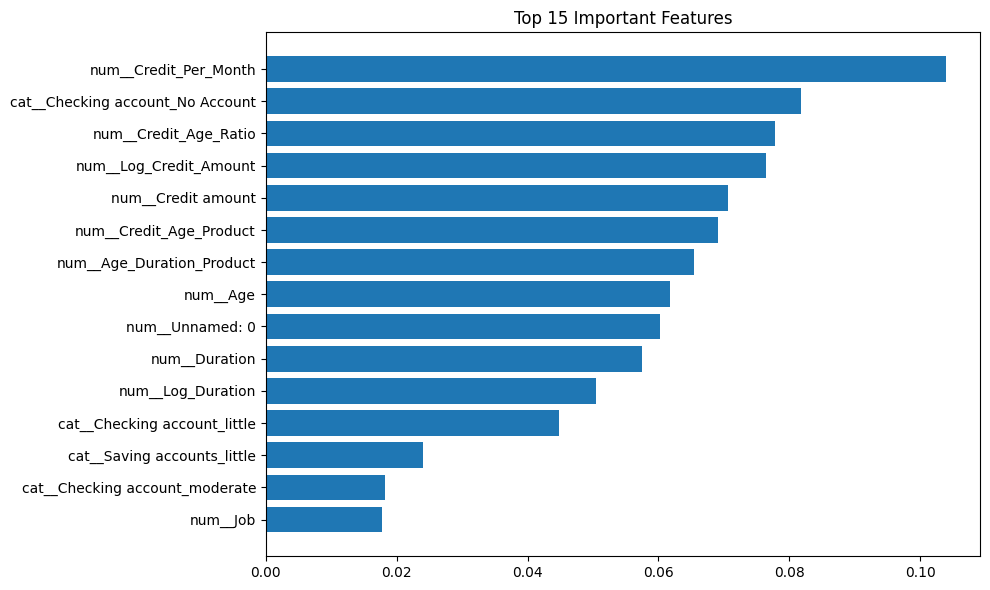

In [12]:
# ==========================================================
# Feature Importance Plot
# ==========================================================

top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.show()

In [13]:
# ==========================================================
# Cross Validation
# ==========================================================

scores = cross_val_score(

    model,

    X,

    y,

    cv=5,

    scoring="accuracy"

)

print(scores)

print()

print("Average Accuracy")

print(scores.mean())

[0.77  0.765 0.73  0.775 0.725]

Average Accuracy
0.753


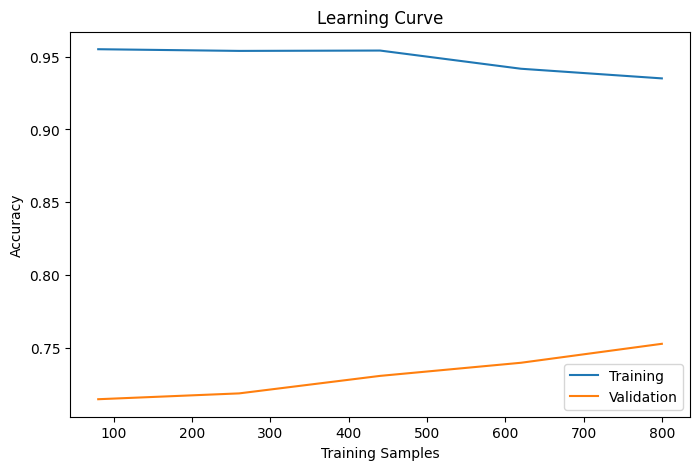

In [14]:
# ==========================================================
# Learning Curve
# ==========================================================

train_sizes, train_scores, test_scores = learning_curve(

    model,

    X,

    y,

    cv=5,

    scoring="accuracy",

    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    )

)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    label="Training"
)

plt.plot(
    train_sizes,
    test_mean,
    label="Validation"
)

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.show()

In [15]:
# ==========================================================
# Save Evaluation Report
# ==========================================================

os.makedirs("../outputs", exist_ok=True)

metrics.to_csv(

    "../outputs/model_report.csv",

    index=False

)

print("Evaluation Report Saved")

Evaluation Report Saved
